<a href="https://colab.research.google.com/github/guavaaaaaaaaaa/python-/blob/main/%E6%95%B8%E6%93%9A%E9%A9%85%E5%8B%95%E7%9A%84%E5%93%81%E9%85%92%E5%B0%88%E5%AE%B6_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 掛接雲端

In [ ]:
from google.colab import drive

# 掛載 Google 雲端硬碟
drive.mount('/content/drive')


Mounted at /content/drive


## 訓練模型

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# 1. 讀取資料
train_df = pd.read_csv("/content/drive/MyDrive/緯育/團專-紅白酒/01-資料/train/train_group_red.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/緯育/團專-紅白酒/01-資料/test/test_group_red.csv")

TARGET_COL = "quality"

# 2. 準備特徵與標籤
X_train_raw = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_test_raw  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

# 標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 3. 建立模型
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="AdamW",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4. 訓練模型
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 5. 定義評估函數並輸出結果
def evaluate_and_print(name, X, y_true):
    # 取得預測機率分佈並轉為類別索引
    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 計算指標 (針對多分類使用 weighted 平均)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)

    # 格式化輸出
    print(f"\n{name}:F1,Precision,recall,Accuracy")
    print(f"{f1:.2f},{precision:.2f},{recall:.2f},{acc:.2f}")

# 執行輸出
evaluate_and_print("train", X_train, y_train)
evaluate_and_print("test", X_test, y_test)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6679 - loss: 0.9443 - val_accuracy: 0.8325 - val_loss: 0.6671
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8168 - loss: 0.6708 - val_accuracy: 0.8325 - val_loss: 0.5617
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8417 - loss: 0.5452 - val_accuracy: 0.8325 - val_loss: 0.5239
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8362 - loss: 0.5267 - val_accuracy: 0.8325 - val_loss: 0.4991
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8144 - loss: 0.5348 - val_accuracy: 0.8325 - val_loss: 0.4808
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8088 - loss: 0.5379 - val_accuracy: 0.8325 - val_loss: 0.4673
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8325 - loss: 0.5261 - val_accuracy: 0.8375 - val_loss: 0.4560
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8404 - loss: 0.4819 - val_accuracy: 0.84

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.07      0.13        14
           1       0.87      0.96      0.91       333
           2       0.59      0.36      0.45        53

    accuracy                           0.85       400
   macro avg       0.82      0.46      0.50       400
weighted avg       0.84      0.85      0.83       400

Confusion Matrix:
[[  1  13   0]
 [  0 320  13]
 [  0  34  19]]


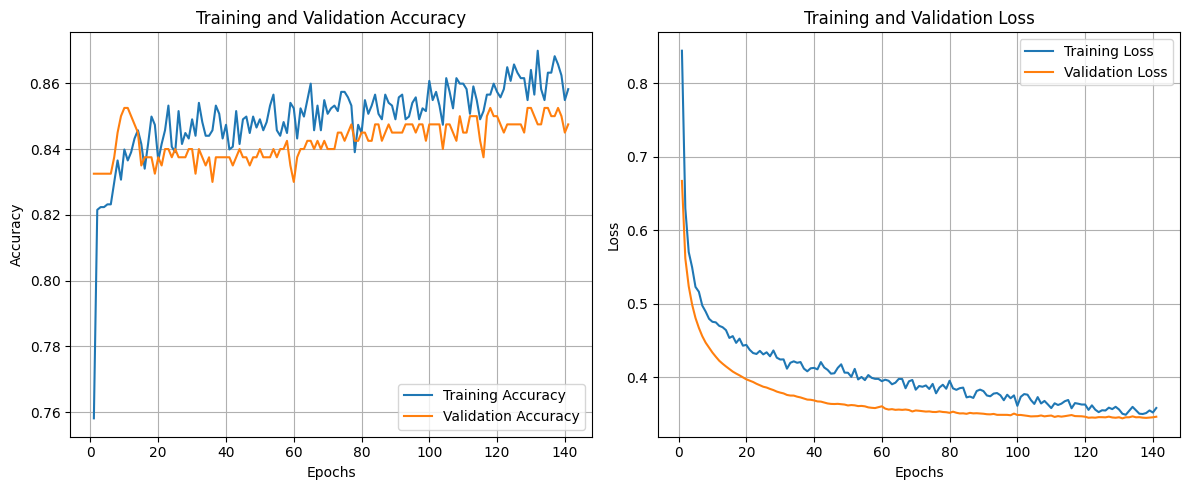

In [ ]:
import matplotlib.pyplot as plt

# 1. 提取訓練過程中的數據
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. 設定畫布大小
plt.figure(figsize=(12, 5))

# 子圖 1：準確率 (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 子圖 2：損失值 (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

##